# Project Analysis

This notebook turns the cleaned data and trained model into a narrative for a public audience. It combines descriptive charts, correlation checks, a forward-looking GDP forecast, and scenario analysis about what would need to change to push growth toward the 6% target discussed in the project report.


In [55]:
import pandas as pd
import seaborn as sns
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

In [57]:
def add_export_import_ratio(x):
    x = x.copy()
    x['export_import_ratio'] = (x['export_of_goods_and_services(US$)_lag1'] 
                                / x['import_of_goods_and_services(US$)_lag1'])
    
    return x.drop(columns=['export_of_goods_and_services(US$)_lag1', 
                        'import_of_goods_and_services(US$)_lag1'], axis=1)

with open('gdp_lasso_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Descriptive Analysis

This section visualizes the historical GDP series and the main macro indicators that appear most relevant in the modelling work. The aim is to show the economic context before moving into prediction and scenario planning.


## Indonesia GDP Growth History

The first chart establishes the baseline pattern of Indonesia's annual GDP growth over time. This is useful for seeing the long-run range, volatility, and recent growth regime that the model is trying to learn from.


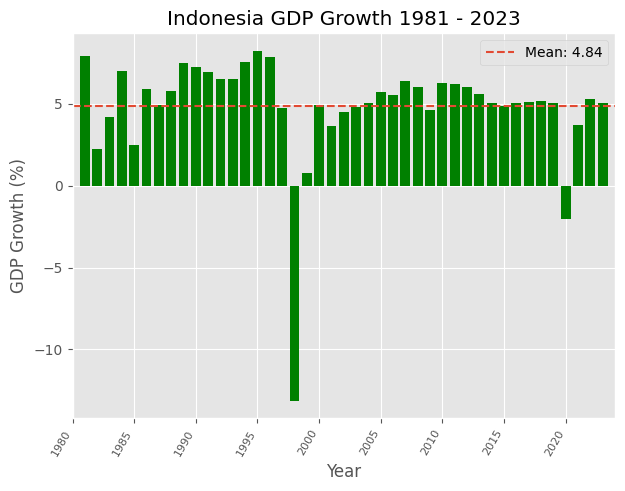

In [59]:

plt.figure(figsize=(7,5))
plt.bar(data.index, data['gdp_growth(%)'], color='g')
plt.style.use('ggplot')

plt.title('Indonesia GDP Growth 1981 - 2023')

plt.xlabel('Year')
plt.xticks(rotation=60, ha='right', fontsize=8); 

plt.ylabel('GDP Growth (%)')
plt.xticks(rotation=60, ha='right', fontsize=8); 

gdp_growth_mean = np.mean(data['gdp_growth(%)'])
plt.axhline(y=np.mean(gdp_growth_mean), linestyle='--', label=f'Mean: {gdp_growth_mean:.2f}')

plt.xlim((1980,2024))
plt.legend()

## Household Consumption and GDP Growth

Household consumption is visualized first because domestic demand is a central part of Indonesia's economy. The paired time-series and regression views show both the historical co-movement and the simple linear relationship with GDP growth.


(1980.0, 2024.0)

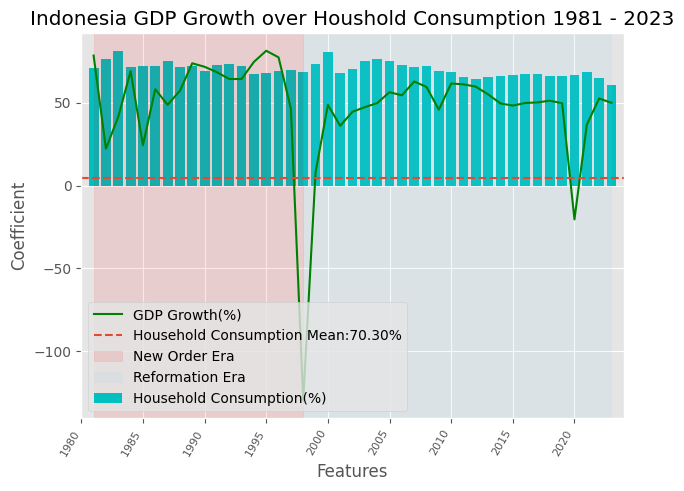

In [60]:
ratio = np.max(data['household_consumption(%)_lag1']) / np.max(data['gdp_growth(%)'])

plt.figure(figsize=(7,5))
plt.plot(data.index, data['gdp_growth(%)'] * ratio, color='g')
plt.bar(data.index, data['household_consumption(%)_lag1'], color='c')
plt.style.use('ggplot')

plt.title('Indonesia GDP Growth over Houshold Consumption 1981 - 2023')

plt.xlabel('Features')
plt.xticks(rotation=60, ha='right', fontsize=8); 

plt.ylabel('Coefficient')
plt.xticks(rotation=60, ha='right', fontsize=8); 

hc_mean = np.mean(data['household_consumption(%)_lag1'])
plt.axhline(y=np.mean(gdp_growth_mean), linestyle='--', label=f'Mean: {gdp_growth_mean:.2f}')

# 1. Highlight the New Order Era (before 1998)
plt.axvspan(1981, 1998, color='red', alpha=0.1, label='New Order')

# 2. Highlight the Reformation Era (after 1998)
plt.axvspan(1998, 2023, color='skyblue', alpha=0.1, label='Reformation Era')

plt.xticks(rotation=60, ha='right', fontsize=8); 

plt.legend(['GDP Growth(%)',f'Household Consumption Mean:{hc_mean:.2f}%', 'New Order Era', 'Reformation Era', 'Household Consumption(%)'])

plt.xlim((1980,2024))

<Axes: title={'center': ' GDP Growth vs Household Consumption Correlation Relationship'}, xlabel='household_consumption(%)_lag1', ylabel='gdp_growth(%)'>

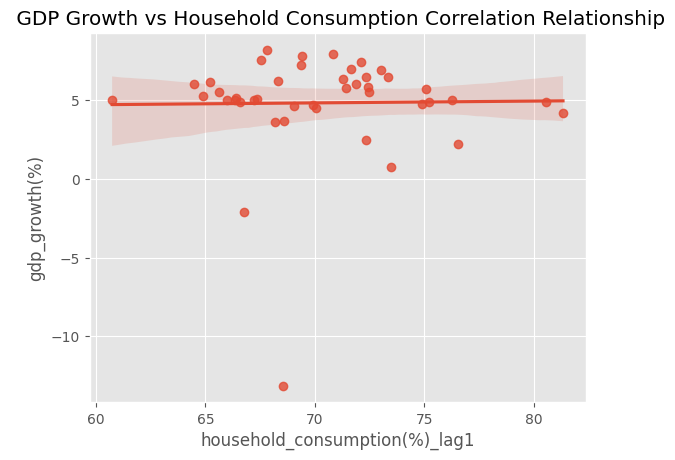

In [61]:
plt.title(" GDP Growth vs Household Consumption Correlation Relationship")
sns.regplot(x=data['household_consumption(%)_lag1'], 
            y=data['gdp_growth(%)'])

## Correlation Analysis

These plots summarize how each variable moves with GDP growth. The purpose is to compare the raw lagged feature space against the engineered feature set and show why some variables were kept for modelling.


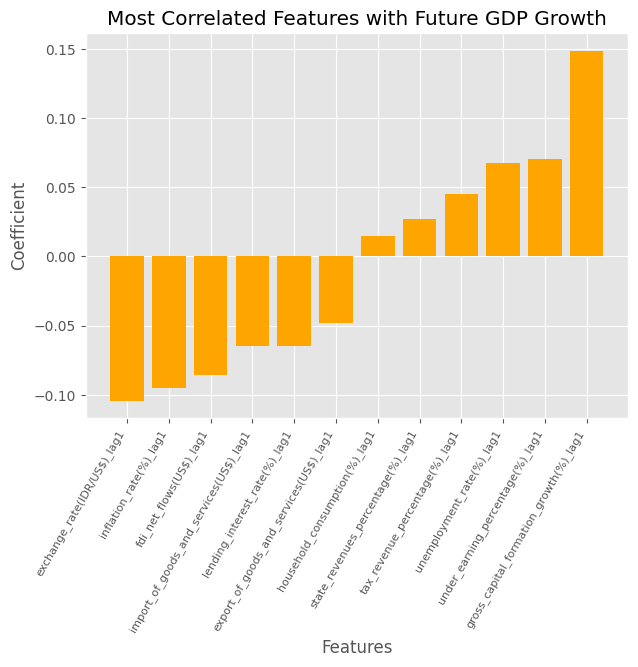

In [62]:
corr = data.corr()['gdp_growth(%)'].sort_values(ascending=True)
corr.drop(labels=['gdp_growth(%)','gdp_growth_lag1(%)','gdp_growth_lag2(%)'], inplace=True)

plt.figure(figsize=(7,5))
plt.bar(corr.index, corr.values, color='orange')
plt.style.use('ggplot')

plt.title('Most Correlated Features with Future GDP Growth')

plt.xlabel('Features')
plt.xticks(rotation=60, ha='right', fontsize=8); 

plt.ylabel('Coefficient')
plt.xticks(rotation=60, ha='right', fontsize=8); 

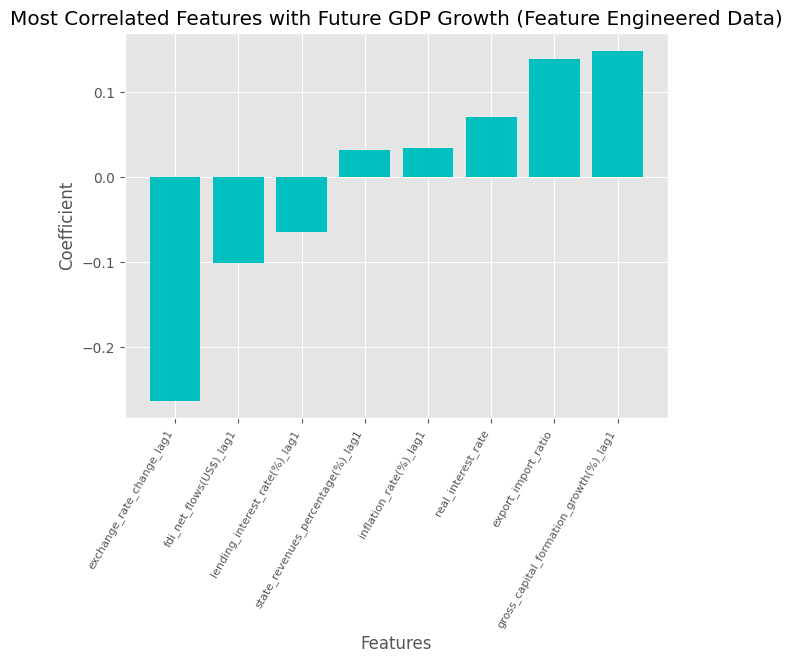

In [63]:
corr = fg_data.corr()['gdp_growth(%)'].sort_values(ascending=True)
corr.drop(labels=['gdp_growth(%)','gdp_growth_lag1(%)','gdp_growth_lag2(%)'], inplace=True)

plt.figure(figsize=(7,5))
plt.bar(corr.index, corr.values, color='c')
plt.style.use('ggplot')

plt.title('Most Correlated Features with Future GDP Growth (Feature Engineered Data)')

plt.xlabel('Features')
plt.xticks(rotation=60, ha='right', fontsize=8); 

plt.ylabel('Coefficient')
plt.xticks(rotation=60, ha='right', fontsize=8); 

## Gross Capital Formation

This section focuses on investment activity. Gross capital formation is examined separately because capital accumulation is one of the clearest channels through which future growth can strengthen.


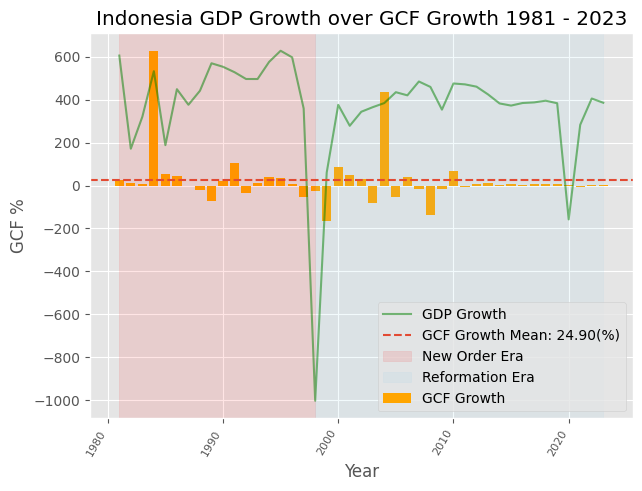

In [64]:
ratio = np.max(data['gross_capital_formation_growth(%)_lag1']) / np.max(data['gdp_growth(%)'])

plt.figure(figsize=(7,5))
plt.plot(data.index, data['gdp_growth(%)']*ratio, color='g', alpha=0.5)
plt.bar(data.index, data['gross_capital_formation_growth(%)_lag1'], color='orange')
plt.style.use('ggplot')

plt.title('Indonesia GDP Growth over GCF Growth 1981 - 2023')

plt.xlabel('Year')
plt.xticks(rotation=60, ha='right', fontsize=8); 

plt.ylabel('GCF %')

gcf_mean = np.mean(data['gross_capital_formation_growth(%)_lag1'])
plt.axhline(y=np.mean(gcf_mean), linestyle='--', label=f'Mean: {gcf_mean:.2f}')

# 1. Highlight the New Order Era (before 1998)
plt.axvspan(1981, 1998, color='red', alpha=0.1, label='New Order')

# 2. Highlight the Reformation Era (after 1998)
plt.axvspan(1998, 2023, color='skyblue', alpha=0.1, label='Reformation Era')

plt.xticks(rotation=60, ha='right', fontsize=8); 

plt.legend(['GDP Growth',f'GCF Growth Mean: {gcf_mean:.2f}(%)', 'New Order Era', 'Reformation Era', 'GCF Growth'])

<Axes: title={'center': ' GDP Growth vs GCF Growth Correlation Relationship'}, xlabel='gross_capital_formation_growth(%)_lag1', ylabel='gdp_growth(%)'>

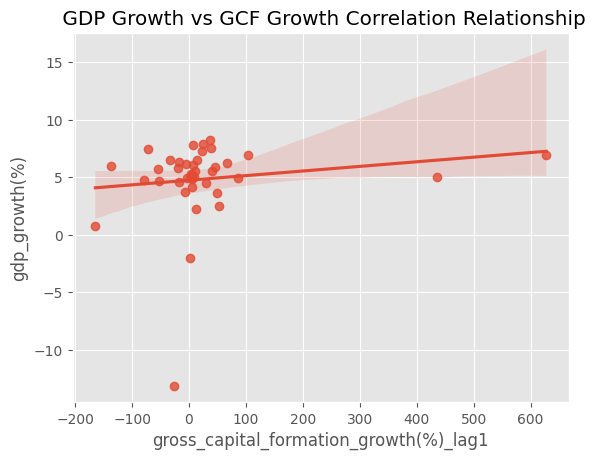

In [65]:
plt.title(" GDP Growth vs GCF Growth Correlation Relationship")
sns.regplot(x=data['gross_capital_formation_growth(%)_lag1'], 
            y=data['gdp_growth(%)'])

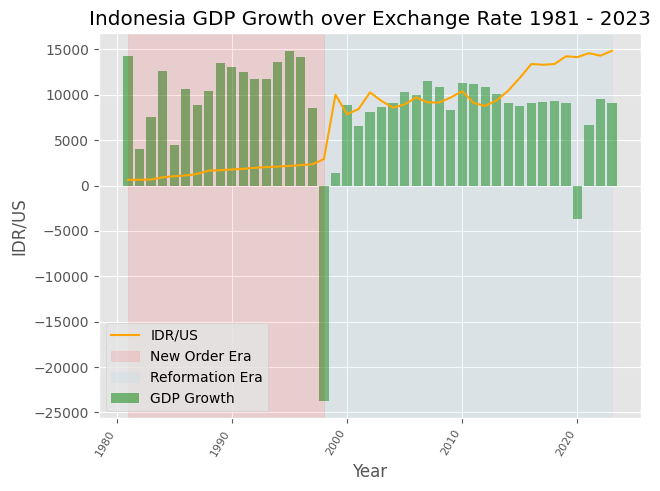

In [66]:
ratio = np.max(data['exchange_rate(IDR/US$)_lag1']) / np.max(data['gdp_growth(%)'])

plt.figure(figsize=(7,5))
plt.bar(data.index, data['gdp_growth(%)'] * ratio, color='g',  alpha=0.5)
plt.plot(data.index, data['exchange_rate(IDR/US$)_lag1'], color='orange')
plt.style.use('ggplot')

plt.title('Indonesia GDP Growth over Exchange Rate 1981 - 2023')

plt.xlabel('Year')
plt.xticks(rotation=60, ha='right', fontsize=8); 

# 1. Highlight the New Order Era (before 1998)
plt.axvspan(1981, 1998, color='red', alpha=0.1, label='New Order')

# 2. Highlight the Reformation Era (after 1998)
plt.axvspan(1998, 2023, color='skyblue', alpha=0.1, label='Reformation Era')

plt.ylabel('IDR/US')
plt.xticks(rotation=60, ha='right', fontsize=8); 

plt.legend(['IDR/US', 'New Order Era', 'Reformation Era','GDP Growth'])

<Axes: title={'center': ' GDP Growth vs Exchange Rate Correlation Relationship'}, xlabel='exchange_rate(IDR/US$)_lag1', ylabel='gdp_growth(%)'>

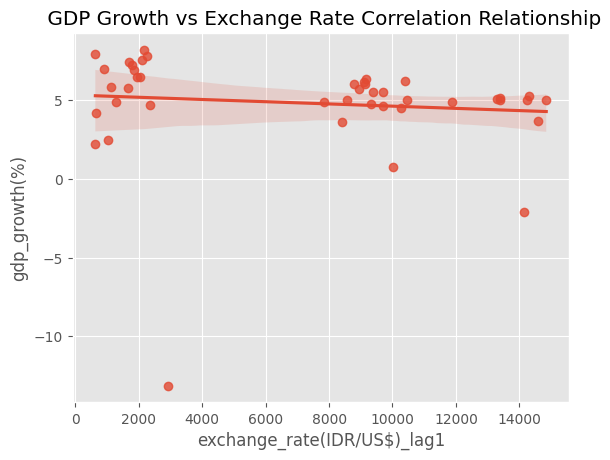

In [67]:
plt.title(" GDP Growth vs Exchange Rate Correlation Relationship")
sns.regplot(x=data['exchange_rate(IDR/US$)_lag1'], 
            y=data['gdp_growth(%)'])

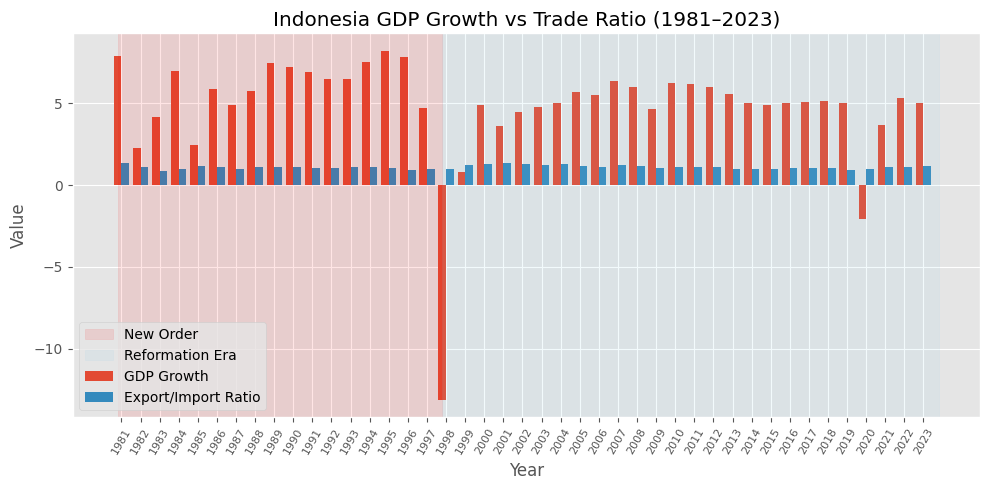

In [68]:
import matplotlib.pyplot as plt

# Align the engineered trade ratio with the raw GDP series before plotting both by year.
combined = data[['gdp_growth(%)']].join(fg_data['export_import_ratio'])

# Sort by year so the plot preserves the time-series order.
combined = combined.sort_index()

plt.figure(figsize=(10,5))
plt.style.use('ggplot')

# Bar width control
width = 0.4
x = range(len(combined.index))

# Bars (side by side)
plt.bar(x, combined['gdp_growth(%)'], width=width, label='GDP Growth')
plt.bar([i + width for i in x], combined['export_import_ratio'], 
        width=width, label='Export/Import Ratio')

# X-axis labels
plt.xticks([i + width/2 for i in x], combined.index, rotation=60, fontsize=8)

plt.title('Indonesia GDP Growth vs Trade Ratio (1981–2023)')
plt.xlabel('Year')
plt.ylabel('Value')

# Highlight eras
plt.axvspan(0, list(combined.index).index(1998), color='red', alpha=0.1, label='New Order')
plt.axvspan(list(combined.index).index(1998), len(x), color='skyblue', alpha=0.1, label='Reformation Era')

plt.legend()
plt.tight_layout()
plt.show()


<Axes: title={'center': ' GDP Growth vs Eexport-Import Ratio Correlation Relationship'}, xlabel='export_import_ratio', ylabel='gdp_growth(%)'>

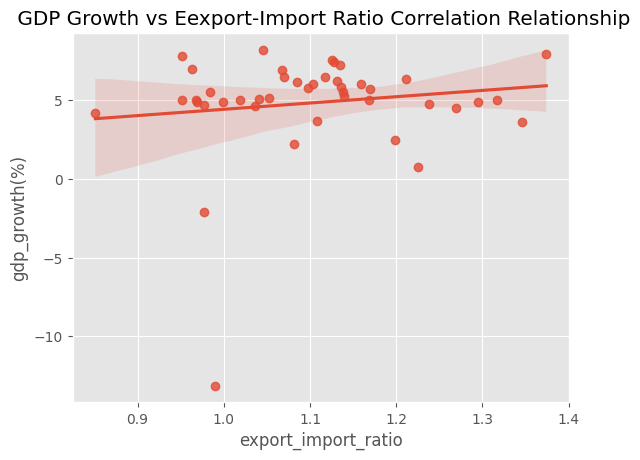

In [69]:
plt.title(" GDP Growth vs Eexport-Import Ratio Correlation Relationship")
sns.regplot(x=fg_data['export_import_ratio'], 
            y=data['gdp_growth(%)'])

## FDI Net Flows

Foreign direct investment is explored as an external financing signal. The goal is to see whether stronger inward investment lines up with stronger GDP outcomes in the historical sample.


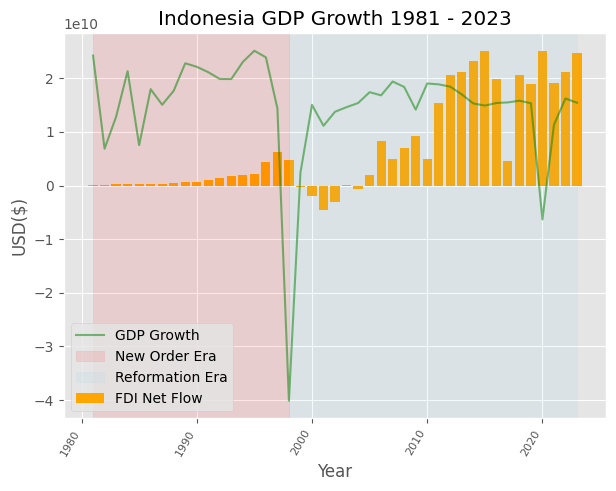

In [70]:
ratio = np.max(data['fdi_net_flows(US$)_lag1']) / np.max(data['gdp_growth(%)'])

plt.figure(figsize=(7,5))
plt.plot(data.index, data['gdp_growth(%)']*ratio, color='g', alpha=0.5)
plt.bar(data.index, data['fdi_net_flows(US$)_lag1'], color='orange')
plt.style.use('ggplot')

plt.title('Indonesia GDP Growth 1981 - 2023')

plt.xlabel('Year')
plt.xticks(rotation=60, ha='right', fontsize=8); 

plt.ylabel('GCF %')


# 1. Highlight the New Order Era (before 1998)
plt.axvspan(1981, 1998, color='red', alpha=0.1, label='New Order')

# 2. Highlight the Reformation Era (after 1998)
plt.axvspan(1998, 2023, color='skyblue', alpha=0.1, label='Reformation Era')

plt.ylabel('USD($)')
plt.xticks(rotation=60, ha='right', fontsize=8); 

plt.legend(['GDP Growth', 'New Order Era', 'Reformation Era', 'FDI Net Flow'])

<Axes: title={'center': ' GDP Growth vs FDI Net Flow Correlation Relationship'}, xlabel='fdi_net_flows(US$)_lag1', ylabel='gdp_growth(%)'>

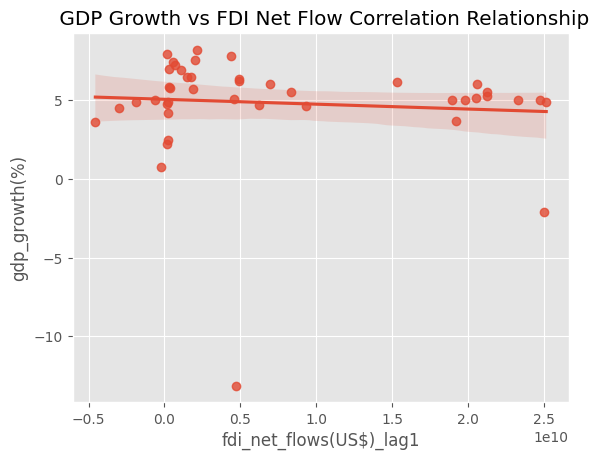

In [71]:
plt.title(" GDP Growth vs FDI Net Flow Correlation Relationship")
sns.regplot(x=data['fdi_net_flows(US$)_lag1'], 
            y=data['gdp_growth(%)'])

# Predictive Analysis

This section uses the trained pipeline to forecast the next GDP growth value from a 2025 macroeconomic scenario. The purpose is to translate the model from backtesting into a concrete forward-looking estimate.


In [74]:
data_2025 = {
        'gdp_growth_lag1(%)' : [5.11], 
        'gdp_growth_lag2(%)' : [5.04],
        'household_consumption(%)_lag1' : [40.98], 
        'fdi_net_flows(US$)_lag1' : [54100000000],
        'gross_capital_formation_growth(%)_lag1' : [5.09],
        'import_of_goods_and_services(US$)_lag1' : [234000000000],
        'export_of_goods_and_services(US$)_lag1' : [282910000000],
        'exchange_rate(IDR/US$)_lag1' : [16474]
}

data_2025_df = pd.DataFrame(data_2025)

gdp_pred = model.predict(data_2025_df)[0]

In [75]:
print ("2025 DATA")
print(f'{data_2025_df.T}\n')
print(f"Expected Growth in 2026:  {gdp_pred:.2f}%\n")

2025 DATA
                                                   0
gdp_growth_lag1(%)                      5.110000e+00
gdp_growth_lag2(%)                      5.040000e+00
household_consumption(%)_lag1           4.098000e+01
fdi_net_flows(US$)_lag1                 5.410000e+10
gross_capital_formation_growth(%)_lag1  5.090000e+00
import_of_goods_and_services(US$)_lag1  2.340000e+11
export_of_goods_and_services(US$)_lag1  2.829100e+11
exchange_rate(IDR/US$)_lag1             1.647400e+04

Expected Growth in 2026:  5.54%



# Prescriptive Analysis

The final analysis asks a policy-style question: what combinations of macro changes would be needed to move growth toward 6%? These scenarios are not causal guarantees, but structured what-if exercises based on the fitted model.


## Single-Lever Scenarios

Each of the following cells changes one major driver at a time. This isolates the directional effect of household consumption, capital formation, FDI, and exports before combining them into broader strategies.


In [76]:
data_2025 = {
        'gdp_growth_lag1(%)' : [5.11], 
        'gdp_growth_lag2(%)' : [5.04],
        'household_consumption(%)_lag1' : [1100.00], 
        'fdi_net_flows(US$)_lag1' : [54100000000],
        'gross_capital_formation_growth(%)_lag1' : [5.09],
        'import_of_goods_and_services(US$)_lag1' : [234000000000],
        'export_of_goods_and_services(US$)_lag1' : [282910000000],
        'exchange_rate(IDR/US$)_lag1' : [16474]
}

data_2025_df = pd.DataFrame(data_2025)


gdp_pred = model.predict(data_2025_df)[0]

report = {'Target Household Consumption' : data_2025['household_consumption(%)_lag1'][0],
          'Predicted GDP Growth' : gdp_pred}
report_df = pd.DataFrame(report, index=[0])
report_df

,Target Household Consumption,Predicted GDP Growth
0,1100.0,6.042494


In [77]:
approach = 'gross_capital_formation_growth(%)_lag1'

data_2025 = {
        'gdp_growth_lag1(%)' : [5.11], 
        'gdp_growth_lag2(%)' : [5.04],
        'household_consumption(%)_lag1' : [40.98], 
        'fdi_net_flows(US$)_lag1' : [54100000000],
        'gross_capital_formation_growth(%)_lag1' : [220.00],
        'import_of_goods_and_services(US$)_lag1' : [234000000000],
        'export_of_goods_and_services(US$)_lag1' : [282910000000],
        'exchange_rate(IDR/US$)_lag1' : [16474]
}

data_2025_df = pd.DataFrame(data_2025)


gdp_pred = model.predict(data_2025_df)[0]

report = {f'Target  {approach}' : data_2025[approach][0],
          'Predicted GDP Growth' : gdp_pred}
report_df = pd.DataFrame(report, index=[0])
report_df

,Target gross_capital_formation_growth(%)_lag1,Predicted GDP Growth
0,220.0,6.036122


In [78]:
approach = 'fdi_net_flows(US$)_lag1'

data_2025 = {
        'gdp_growth_lag1(%)' : [5.11], 
        'gdp_growth_lag2(%)' : [5.04],
        'household_consumption(%)_lag1' : [40.98], 
        'fdi_net_flows(US$)_lag1' : [110000000000], # Raise FDI from the baseline scenario value to test a stronger investment case.
        'gross_capital_formation_growth(%)_lag1' : [5.09],
        'import_of_goods_and_services(US$)_lag1' : [234000000000],
        'export_of_goods_and_services(US$)_lag1' : [282910000000], 
        'exchange_rate(IDR/US$)_lag1' : [16474]
}

data_2025_df = pd.DataFrame(data_2025)


gdp_pred = model.predict(data_2025_df)[0]

data_2025_df = pd.DataFrame(data_2025)


gdp_pred = model.predict(data_2025_df)[0]

report = {f'Target  {approach}' : data_2025[approach][0],
          'Predicted GDP Growth' : gdp_pred}
report_df = pd.DataFrame(report, index=[0])
report_df


,Target fdi_net_flows(US$)_lag1,Predicted GDP Growth
0,110000000000,6.083553


In [79]:
approach = 'export_of_goods_and_services(US$)_lag1'

data_2025 = {
        'gdp_growth_lag1(%)' : [5.11], 
        'gdp_growth_lag2(%)' : [5.04],
        'household_consumption(%)_lag1' : [40.98], 
        'fdi_net_flows(US$)_lag1' : [54100000000],
        'gross_capital_formation_growth(%)_lag1' : [5.09],
        'import_of_goods_and_services(US$)_lag1' : [220000000000],
        'export_of_goods_and_services(US$)_lag1' : [360000000000], # from 282910000000
        'exchange_rate(IDR/US$)_lag1' : [16474]
}

data_2025_df = pd.DataFrame(data_2025)


gdp_pred = model.predict(data_2025_df)[0]

data_2025_df = pd.DataFrame(data_2025)


gdp_pred = model.predict(data_2025_df)[0]

report = {f'Target  {approach}' : data_2025[approach][0],
          'Predicted GDP Growth' : gdp_pred}
report_df = pd.DataFrame(report, index=[0])
report_df

,Target export_of_goods_and_services(US$)_lag1,Predicted GDP Growth
0,360000000000,6.031469


In [80]:
changed_data_2025 = {
        'gdp_growth_lag1(%)' : [5.11], 
        'gdp_growth_lag2(%)' : [5.04],
        'household_consumption(%)_lag1' : [52.00], 
        'fdi_net_flows(US$)_lag1' : [54100000000], # Increase FDI relative to the baseline scenario as part of a combined policy package.
        'gross_capital_formation_growth(%)_lag1' : [8.00], # from 5.09%
        'import_of_goods_and_services(US$)_lag1' : [240000000000],# from 234000000000
        'export_of_goods_and_services(US$)_lag1' : [320000000000], # from 282910000000
        'exchange_rate(IDR/US$)_lag1' : [16474]
}

changed_data_2025_df = pd.DataFrame(data_2025)


gdp_pred = model.predict(changed_data_2025_df)[0]

changed_data_2025_df = pd.DataFrame(changed_data_2025)


gdp_pred = model.predict(changed_data_2025_df)[0]
gdp_pred


5.69346788956177

## Combined Strategy Review

After testing single-variable changes, the notebook shifts to combined packages of improvements. This is more realistic because achieving higher GDP growth would likely require several macro conditions to improve together.


## Moderate Approach

This scenario tests a more achievable bundle of improvements. The purpose is to show what a gradual path toward higher growth could look like without assuming extreme jumps in every variable.


In [82]:
report_dict = {

    'changes': {
        'household_consumption(%)_lag1': {
            'current': 40.98,
            'target': 52.00,
            'change': round(52.00 - 40.98, 2)
        },
        'fdi_net_flows(US$)_lag1': {
            'current': 54100000000,
            'target': 65000000000,
            'change': 65000000000 - 54100000000
        },
        'gross_capital_formation_growth(%)_lag1': {
            'current': 5.09,
            'target': 8.00,
            'change': round(8.00 - 5.09, 2)
        },
        'import_of_goods_and_services(US$)_lag1': {
            'current': 234000000000,
            'target': 240000000000,
            'change': 240000000000 - 234000000000
        },
        'export_of_goods_and_services(US$)_lag1': {
            'current': 282910000000,
            'target': 320000000000,
            'change': 320000000000 - 282910000000
        }
    }
}

# Convert nested dict → DataFrame
df = pd.DataFrame.from_dict(report_dict['changes'], orient='index')

# Optional: clean index name
df.index.name = 'Variable'

df_pretty = df.copy()

df_pretty = df_pretty.apply(
    lambda col: col.map(
        lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x
    )
)

print("--MODERATE APPROACH--")
print(f"predicted_gdp_growth: {round(gdp_pred, 2)}")
df_pretty


--MODERATE APPROACH--
predicted_gdp_growth: 5.69


,current,target,change
Variable,,,
household_consumption(%)_lag1,40.98,52.00,11.02
fdi_net_flows(US$)_lag1,"54,100,000,000.00","65,000,000,000.00","10,900,000,000.00"
gross_capital_formation_growth(%)_lag1,5.09,8.00,2.91
import_of_goods_and_services(US$)_lag1,"234,000,000,000.00","240,000,000,000.00","6,000,000,000.00"
export_of_goods_and_services(US$)_lag1,"282,910,000,000.00","320,000,000,000.00","37,090,000,000.00"


## Aggressive Approach

This final scenario tests a much stronger macro improvement package. It illustrates the scale of change the model associates with reaching the 6% growth target more decisively.


In [88]:
changed_data_2025 = {
        'gdp_growth_lag1(%)' : [6.11], 
        'gdp_growth_lag2(%)' : [6.04],
        'household_consumption(%)_lag1' : [52.00], 
        'fdi_net_flows(US$)_lag1' : [65000000000], # Push FDI higher again to test a more aggressive growth strategy.
        'gross_capital_formation_growth(%)_lag1' : [10.00], # from 5.09%
        'import_of_goods_and_services(US$)_lag1' : [260000000000],# from 234000000000
        'export_of_goods_and_services(US$)_lag1' : [850000000000], # from 282910000000
        'exchange_rate(IDR/US$)_lag1' : [16474]
}

changed_data_2025_df = pd.DataFrame(data_2025)


gdp_pred = model.predict(changed_data_2025_df)[0]

changed_data_2025_df = pd.DataFrame(changed_data_2025)


gdp_pred = model.predict(changed_data_2025_df)[0]
gdp_pred


8.171451514396335

In [84]:
report_dict = {

    'changes': {
        'household_consumption(%)_lag1': {
            'current': 40.98,
            'target': 52.00,
            'change': round(52.00 - 40.98, 2)
        },
        'fdi_net_flows(US$)_lag1': {
            'current': 54100000000,
            'target': 65000000000,
            'change': 65000000000 - 54100000000
        },
        'gross_capital_formation_growth(%)_lag1': {
            'current': 5.09,
            'target': 10.00,
            'change': round(10.00 - 5.09, 2)
        },
        'import_of_goods_and_services(US$)_lag1': {
            'current': 234000000000,
            'target': 240000000000,
            'change': 240000000000 - 234000000000
        },
        'export_of_goods_and_services(US$)_lag1': {
            'current': 282910000000,
            'target': 380000000000,
            'change': 380000000000 - 282910000000
        }
    }
}

# Convert nested dict → DataFrame
df = pd.DataFrame.from_dict(report_dict['changes'], orient='index')

# Optional: clean index name
df.index.name = 'Variable'

df_pretty = df.copy()

df_pretty = df_pretty.apply(
    lambda col: col.map(
        lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x
    )
)

print("--AGRESSIVE APPROACH: High Export and GFC Growth--")
print(f"predicted_gdp_growth: {round(gdp_pred, 2)}")
df_pretty

--AGRESSIVE APPROACH: High Export and GFC Growth--
predicted_gdp_growth: 6.02


,current,target,change
Variable,,,
household_consumption(%)_lag1,40.98,52.00,11.02
fdi_net_flows(US$)_lag1,"54,100,000,000.00","65,000,000,000.00","10,900,000,000.00"
gross_capital_formation_growth(%)_lag1,5.09,10.00,4.91
import_of_goods_and_services(US$)_lag1,"234,000,000,000.00","240,000,000,000.00","6,000,000,000.00"
export_of_goods_and_services(US$)_lag1,"282,910,000,000.00","380,000,000,000.00","97,090,000,000.00"
